In [1]:
import sys
import os
import numpy as np

#Add the 'oracle' directory to the Python path
sys.path.append(os.path.join(os.getcwd(), 'oracle'))
import oracle
data = oracle.q2_train_test_emnist(23746,"EMNIST/emnist-balanced-train.csv","EMNIST/emnist-balanced-test.csv")
print(data[0].shape)
print(data[1].shape)
print(data[0])





/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)


(4800, 785)
(800, 785)
[[17  0  0 ...  0  0  0]
 [17  0  0 ...  0  0  0]
 [17  0  0 ...  0  0  0]
 ...
 [30  0  0 ...  0  0  0]
 [30  0  0 ...  0  0  0]
 [17  0  0 ...  0  0  0]]


In [2]:
data_17 =[]
data_30 = []
for i in range(len(data[0])):
    #print(data[0][i])
    if data[0][i][0] == 17:
        data_17.append([np.longdouble(data[0][i][j]) for j in range(len(data[0][i]))])
    if data[0][i][0] == 30:
        data_30.append([np.longdouble(data[0][i][j]) for j in range(len(data[0][i]))])
data_17 = np.array(data_17)
data_30 = np.array(data_30)

# mean_list_17 = []
# std_list_17 = []
# mean_list_30 = []
# std_list_30 = []
# for i in range(1, 785):
#     mean_list_17.append(np.longdouble(np.mean(data_17[:, i])))
#     std_list_17.append(np.longdouble(np.std(data_17[:, i])))
#     mean_list_30.append(np.longdouble(np.mean(data_30[:, i])))
#     std_list_30.append(np.longdouble(np.std(data_30[:, i])))

mean_list_17 = np.mean(data_17[:, 1:], axis=0)
cov_matrix_17 = np.cov(data_17[:, 1:], rowvar=False)
mean_list_30 = np.mean(data_30[:, 1:], axis=0)
cov_matrix_30 = np.cov(data_30[:, 1:], rowvar=False)



In [43]:
def Bayes(epsilon, x,mean_list_17,mean_list_30,std_list_17,std_list_30,p_1):
    p_1 = np.longdouble(p_1)
    # log_p_17 = 0
    # log_p_30 = 0
    p_17 = 1
    p_30 = 1

    for i in range(784):
        if std_list_17[i] == 0 or std_list_30[i] == 0:
            continue
        p_17 *= np.longdouble(np.exp(-0.5 * (x[i] - mean_list_17[i]) ** 2 / std_list_17[i] ** 2))/ (std_list_17[i] * np.sqrt(2 * np.pi))
        p_30 *= np.longdouble(np.exp(-0.5 * (x[i] - mean_list_30[i]) ** 2 / std_list_30[i] ** 2))/ (std_list_30[i] * np.sqrt(2 * np.pi))
        
    #     log_p_17 += np.longdouble(-0.5 * (x[i] - mean_list_17[i]) ** 2 / std_list_17[i] ** 2 - np.log(std_list_17[i] * np.sqrt(2 * np.pi)))
    #     log_p_30 += np.longdouble(-0.5 * (x[i] - mean_list_30[i]) ** 2 / std_list_30[i] ** 2 - np.log(std_list_30[i] * np.sqrt(2 * np.pi)))

    # p_17 = np.exp(np.longdouble(log_p_17))
    # p_30 = np.exp(np.longdouble(log_p_30))
    #print(p_17/(p_17+p_30))
    print("p_17", p_17)
    print(" p_30", p_30)
    print(p_17*p_1/(p_17*p_1+p_30*(1-p_1)))
    if p_17*p_1/(p_17*p_1+p_30*(1-p_1)) >=  0.5 + epsilon:
        return 17
    elif p_17*p_1/(p_17*p_1+p_30*(1-p_1)) <= 0.5 - epsilon:
        return 30
    return 0

In [44]:
def classification(e,test,data_17,data_30,p_1 = 0.5):
    misclassified = 0
    rejection = 0
    non_rejected = 0
    mean_list_17 = np.mean(data_17[:, 1:], axis=0)
    cov_matrix_17 = np.std(data_17[:, 1:], axis = 0)
    mean_list_30 = np.mean(data_30[:, 1:], axis=0)
    cov_matrix_30 = np.std(data_30[:, 1:], axis = 0)
    for i in range(len(test)):
        val = Bayes(e,test[i][1:],mean_list_17,cov_matrix_17,mean_list_30,cov_matrix_30,p_1)
        if val == 0:
            rejection += 1
        else :
            non_rejected += 1
            if val != test[i][0]:
                misclassified += 1
       
    print(misclassified)
    print(rejection)
    return misclassified/non_rejected, rejection/len(test)
    

In [9]:
x = [0.01,0.1,0.25,0.4]
data_new = [classification(i,data[1]) for i in x]
y = [data_new[i][0] for i in range(len(data_new))]
z = [data_new[i][1] for i in range(len(data_new))]



KeyboardInterrupt: 

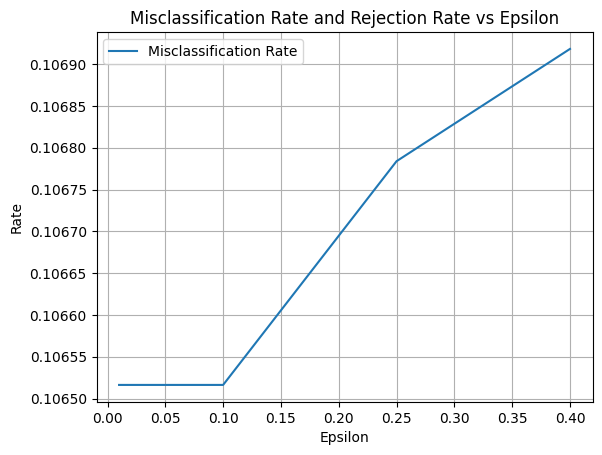

[0.10651629072681704, 0.10651629072681704, 0.10678391959798995, 0.1069182389937107]
[0.0025, 0.0025, 0.005, 0.00625]


In [34]:
import matplotlib.pyplot as plt
plt.plot(x, y)
#plt.plot(x, z)
plt.grid(True)
plt.legend(['Misclassification Rate',])
plt.xlabel('Epsilon')
plt.ylabel('Rate')
plt.title('Misclassification Rate and Rejection Rate vs Epsilon')
plt.show()
print(y)
print(z)

In [28]:
test_17 = []
for i in range(len(data[1])):
    if data[1][i][0] == 17:
        test_17.append(data[1][i])
test_17 = np.array(test_17)
test_30 = []
for i in range(len(data[1])):
    if data[1][i][0] == 30:
        test_30.append(data[1][i])
test_30 = np.array(test_30)


In [29]:
import random
random.shuffle(test_17)
random.shuffle(test_30)

test_17_60 = test_17[:int(0.6*len(test_17))]
test_30_40 = test_30[:int(0.4*len(test_30))]
# print(len(test_17_60))
# print(len(test_30_40))
# print(test_30_40[0])

random.shuffle(test_17)
random.shuffle(test_30)

test_17_80 = test_17[:int(0.8*len(test_17))]
test_30_20 = test_30[:int(0.2*len(test_30))]

random.shuffle(test_17)
random.shuffle(test_30)

test_17_90 = test_17[:int(0.9*len(test_17))]
test_30_10 = test_30[:int(0.1*len(test_30))]

random.shuffle(test_17)
random.shuffle(test_30)

test_17_99 = test_17[:int(0.99*len(test_17))]
test_30_1 = test_30[:int(0.01*len(test_30))]


In [30]:
random.shuffle(data_17)
random.shuffle(data_30)

train_17_60 = data_17[:int(0.6*len(data_17))]
train_30_40 = data_30[:int(0.4*len(data_30))]
# print(len(train_17_60))

random.shuffle(data_17)
random.shuffle(data_30)

train_17_80 = data_17[:int(0.8*len(data_17))]
train_30_20 = data_30[:int(0.2*len(data_30))]

random.shuffle(data_17)
random.shuffle(data_30)

train_17_90 = data_17[:int(0.9*len(data_17))]
train_30_10 = data_30[:int(0.1*len(data_30))]

random.shuffle(data_17)
random.shuffle(data_30)

train_17_99 = data_17[:int(0.99*len(data_17))]
train_30_1 = data_30[:int(0.01*len(data_30))]



In [45]:
epsilons = [0.1,0.25,0.4,0.49]
data_60_40 = [classification(i,np.concatenate((test_17_60,test_30_40)),train_17_60,train_30_40,0.6) for i in epsilons]
misclass_60_40 = [data_60_40[i][0] for i in range(len(data_60_40))]
rej_60_40 = [data_60_40[i][1] for i in range(len(data_60_40))]
print(misclass_60_40)
print(rej_60_40)

plt.plot(epsilons, misclass_60_40)

p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p

/tmp/ipykernel_48073/2882747078.py:22: RuntimeWarning: invalid value encountered in scalar divide
  print(p_17*p_1/(p_17*p_1+p_30*(1-p_1)))
/tmp/ipykernel_48073/2882747078.py:23: RuntimeWarning: invalid value encountered in scalar divide
  if p_17*p_1/(p_17*p_1+p_30*(1-p_1)) >=  0.5 + epsilon:
/tmp/ipykernel_48073/2882747078.py:25: RuntimeWarning: invalid value encountered in scalar divide
  elif p_17*p_1/(p_17*p_1+p_30*(1-p_1)) <= 0.5 - epsilon:


p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p_30 0.0
nan
p_17 0.0
 p

ZeroDivisionError: division by zero

28
0
28
0
28
0
28
0
[0.07, 0.07, 0.07, 0.07]
[0.0, 0.0, 0.0, 0.0]


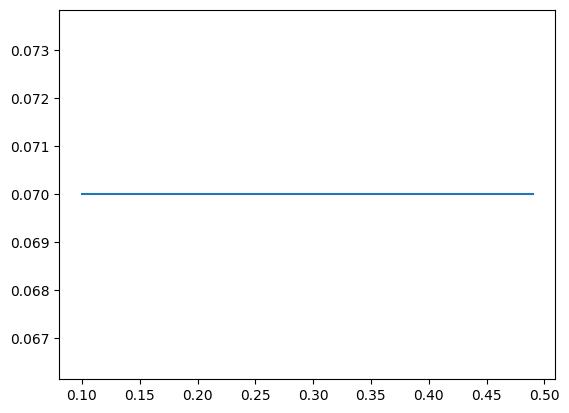

In [88]:
data_80_20 = [classification(i,np.concatenate((test_17_80,test_30_20)),0.8) for i in epsilons]
misclass_80_20 = [data_80_20[i][0] for i in range(len(data_80_20))]
rej_80_20 = [data_80_20[i][1] for i in range(len(data_80_20))]
print(misclass_80_20)
print(rej_80_20)

plt.plot(epsilons, misclass_80_20)


32
0
32
0
32
0
32
0
[0.08, 0.08, 0.08, 0.08]
[0.0, 0.0, 0.0, 0.0]


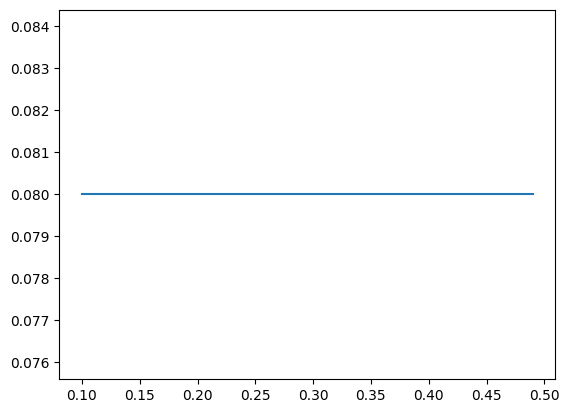

In [ ]:
data_90_10 = [classification(i,np.concatenate((test_17_90,test_30_10)),0.9) for i in epsilons]
misclass_90_10 = [data_90_10[i][0] for i in range(len(data_90_10))]
rej_90_10 = [data_90_10[i][1] for i in range(len(data_90_10))]
print(misclass_90_10)
print(rej_90_10)

plt.plot(epsilons, misclass_90_10)


35
0
35
0
35
0
35
0
[0.0875, 0.0875, 0.0875, 0.0875]
[0.0, 0.0, 0.0, 0.0]


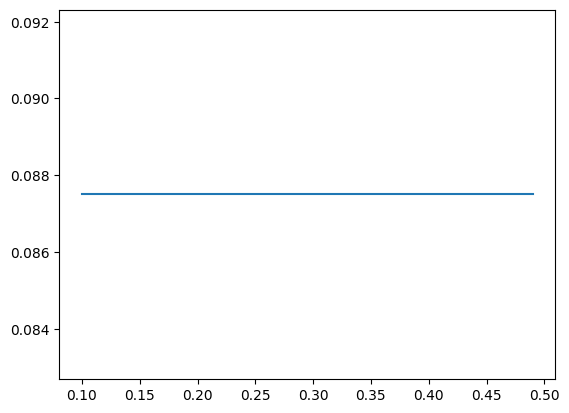

In [90]:
data_99_1 = [classification(i,np.concatenate((test_17_99,test_30_1)),0.99) for i in epsilons]
misclass_99_1 = [data_99_1[i][0] for i in range(len(data_99_1))]
rej_99_1 = [data_99_1[i][1] for i in range(len(data_99_1))]
print(misclass_99_1)
print(rej_99_1)

plt.plot(epsilons, misclass_99_1)